Test

## Dependencies

In [185]:
pip install matplotlib
pip install matplotlib seaborn
pip install xgboost==2.1.0
pip install pandas numpy scikit-learn
pip install statsmodels
!pip install vaderSentiment
!pip install -U sentence-transformers

SyntaxError: invalid syntax (3107298723.py, line 1)

In [ ]:
#Core
import numpy as np
import pandas as pd
#Visualization
import matplotlib.pyplot as plt
import seaborn as sns
#Preprocessing
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
#Modeling
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import statsmodels.formula.api as smf
#NLP and Embeddings
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sentence_transformers import SentenceTransformer
#Dimensionality reduction
from sklearn.decomposition import PCA
#Explainability
import shap
#Reproducibility
np.random.seed(42)

XGBoost version: 2.1.0


# File path

In [ ]:
consumer_path = "/Users/bognarlili/Documents/consumer_survey_dataset_humanlike_case.csv"
sensory_path = "/Users/bognarlili/Documents/sensory_panel_dataset_case.csv"

consumer = pd.read_csv(consumer_path)
sensory = pd.read_csv(sensory_path)

print("Consumer shape:", consumer.shape)
print("Sensory shape:", sensory.shape)

print("\nConsumer head:")
print(consumer.head(5))

print("\nSensory head:")
print(sensory.head(5))


Consumer shape: (3000, 8)
Sensory shape: (30, 9)

Consumer head:
        Market  Flavour Brand  Respondent_ID  Overall_Opinion  Ease_to_drink  \
0  Netherlands  Vanilla  Ours              1         7.313883       2.266295   
1  Netherlands  Vanilla  Ours              2         5.021614       4.560996   
2  Netherlands  Vanilla  Ours              3         6.028031       4.116906   
3  Netherlands  Vanilla  Ours              4         6.338538       4.039265   
4  Netherlands  Vanilla  Ours              5         7.103402       2.374331   

   Sweetness_JAR                                          Open_Text  
0       2.369352  Good balance of flavor, not too sweet, feels l...  
1       5.000000  I liked the taste but the consistency was a bi...  
2       1.803471  The flavor was okay but not something I’d crav...  
3       3.576949  The sweetness level was fine but I didn’t feel...  
4       2.843484  Very convenient packaging and easy to drink in...  

Sensory head:
        Market     

# EDA

In [ ]:
for df in [consumer, sensory]:
    #normalise
    df["Brand"] = df["Brand"].astype(str).str.strip().str.title()
    df["Flavour"] = df["Flavour"].astype(str).str.strip().str.title()

#keep uniqe only
print("Unique Brands in consumer:", consumer["Brand"].unique())
print("Unique Brands in sensory:", sensory["Brand"].unique())

print("\nUnique Flavours in consumer:", consumer["Flavour"].unique())
print("Unique Flavours in sensory:", sensory["Flavour"].unique())

Unique Brands in consumer: ['Ours' 'Competitor']
Unique Brands in sensory: ['Ours' 'Competitor']

Unique Flavours in consumer: ['Vanilla' 'Strawberry' 'Chocolate']
Unique Flavours in sensory: ['Vanilla' 'Strawberry' 'Chocolate']


## Integration (merge)

In [ ]:
#Join based on Market + Brand + Flavour
data = consumer.merge(
    sensory,
    on=["Market", "Brand", "Flavour"],
    how="left"   
)
print(data.head(5))
data.to_csv("merged_dataset.csv", index=False)
print(data.columns.tolist())

        Market  Flavour Brand  Respondent_ID  Overall_Opinion  Ease_to_drink  \
0  Netherlands  Vanilla  Ours              1         7.313883       2.266295   
1  Netherlands  Vanilla  Ours              2         5.021614       4.560996   
2  Netherlands  Vanilla  Ours              3         6.028031       4.116906   
3  Netherlands  Vanilla  Ours              4         6.338538       4.039265   
4  Netherlands  Vanilla  Ours              5         7.103402       2.374331   

   Sweetness_JAR                                          Open_Text  \
0       2.369352  Good balance of flavor, not too sweet, feels l...   
1       5.000000  I liked the taste but the consistency was a bi...   
2       1.803471  The flavor was okay but not something I’d crav...   
3       3.576949  The sweetness level was fine but I didn’t feel...   
4       2.843484  Very convenient packaging and easy to drink in...   

       Sweet   Metallic      Grain     Butter    Vanilla       Milk  
0  51.583902  56.96924

## Missing Values and Duplicates

In [ ]:
before = data.shape[0]
data = data.drop_duplicates()
after = data.shape[0]
print(f"Removed {before - after} duplicate rows (if any).")
missing = data.isna().sum().sort_values(ascending=False)
print("\nTop 15 columns with missing values:")
print(missing.head(15))

Removed 0 duplicate rows (if any).

Top 15 columns with missing values:
Market             0
Flavour            0
Brand              0
Respondent_ID      0
Overall_Opinion    0
Ease_to_drink      0
Sweetness_JAR      0
Open_Text          0
Sweet              0
Metallic           0
Grain              0
Butter             0
Vanilla            0
Milk               0
dtype: int64


## Scale normalization
Survey scales (1–10, 1–5, 1–100) were normalized to 0–1 for consistency.JAR scores were converted to distance from the ideal (|JAR–3|) to show how far each product is from “just right,” helping connect open-text feedback (e.g., “too sweet”) with sensory data.

Sensory scores (1–100) were scaled to 0–1 to match other questions (1–5, 1–10).This ensures the model treats all features equally and helps simulate effects like reducing sweetness from 0.6 to 0.5.

In [ ]:
data["overall_norm"] = data["Overall_Opinion"] / 10.0
data["ease_norm"] = data["Ease_to_drink"] / 5.0
data["sweetness_misfit"] = (data["Sweetness_JAR"] - 3).abs()

sensory_cols = ["Sweet", "Metallic", "Grain", "Butter", "Vanilla", "Milk"]

for col in sensory_cols:
    data[col + "_norm"] = data[col] / 100.0

## Text Cleaning
Open-text answers were standardized (lowercased, punctuation/extra spaces removed) to make “Too Sweet!”, “too sweet” and “too sweet…” identical.
This ensures consistent input for sentiment, topic, or BERT-based text analysis later.

In [186]:
data["Open_Text_clean"] = (
    data["Open_Text"]
    .astype(str)
    .str.lower()
    .str.replace(r"[^a-z\s]", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

## Categorical Encoding
Categorical fields like Market, Flavour, and Brand were one-hot encoded for model readiness.This allows the model to capture market differences

In [ ]:
data_model = pd.get_dummies(
    data,
    columns=["Market", "Flavour", "Brand"],
    drop_first=True
)

## Correlation Analysis

In [ ]:
cols_to_drop_for_model = ["Overall_Opinion", "overall_norm", "Open_Text", "Open_Text_clean"]
X = data_model.drop(columns=cols_to_drop_for_model)
y = data_model["Overall_Opinion"]

<Figure size 1000x600 with 0 Axes>

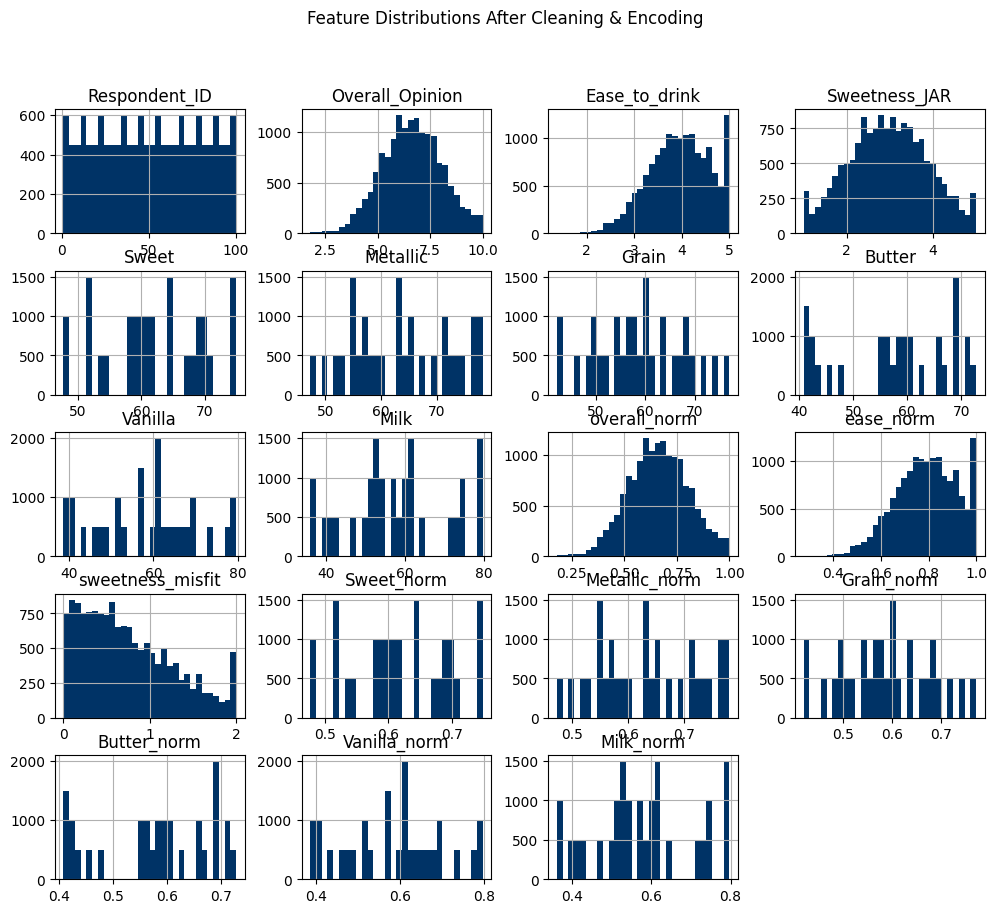

In [ ]:
plt.figure(figsize=(10,6))
data_model.hist(bins=30, figsize=(12,10), color='#003366')
plt.suptitle("Feature Distributions After Cleaning & Encoding")
plt.show()

Correlation matrix (numeric + encoded)

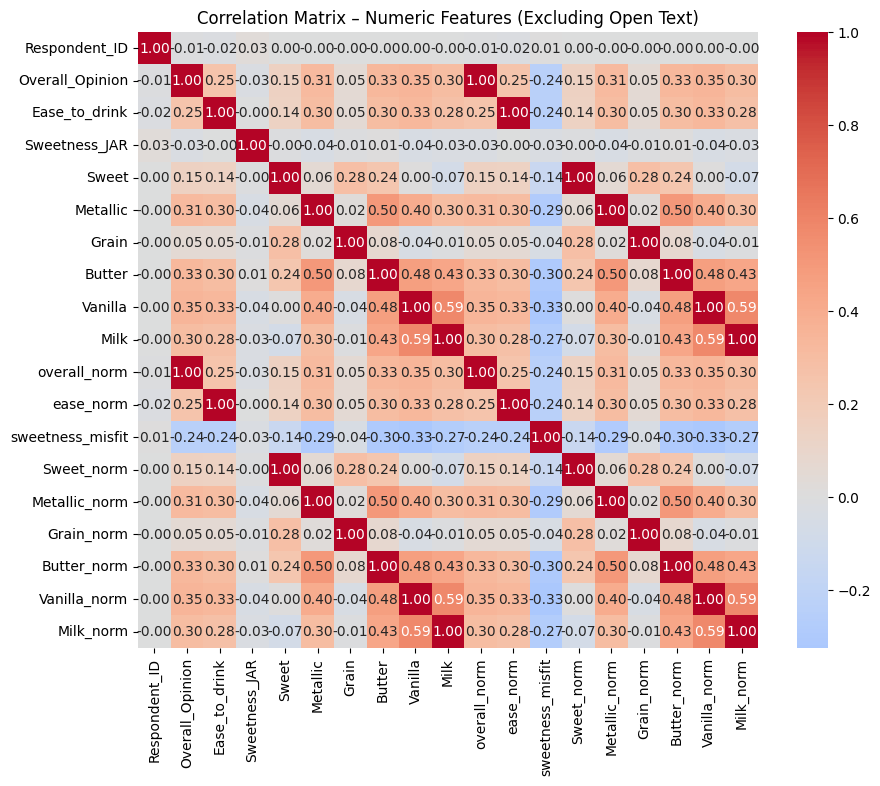

In [ ]:
#exclude text columns
num_df = data_model.drop(columns=["Open_Text", "Open_Text_clean"], errors="ignore")
num_df = num_df.select_dtypes(include=["number"])
#correlation only for numeric columns
corr = num_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Matrix – Numeric Features (Excluding Open Text)")
plt.show()#heatmap

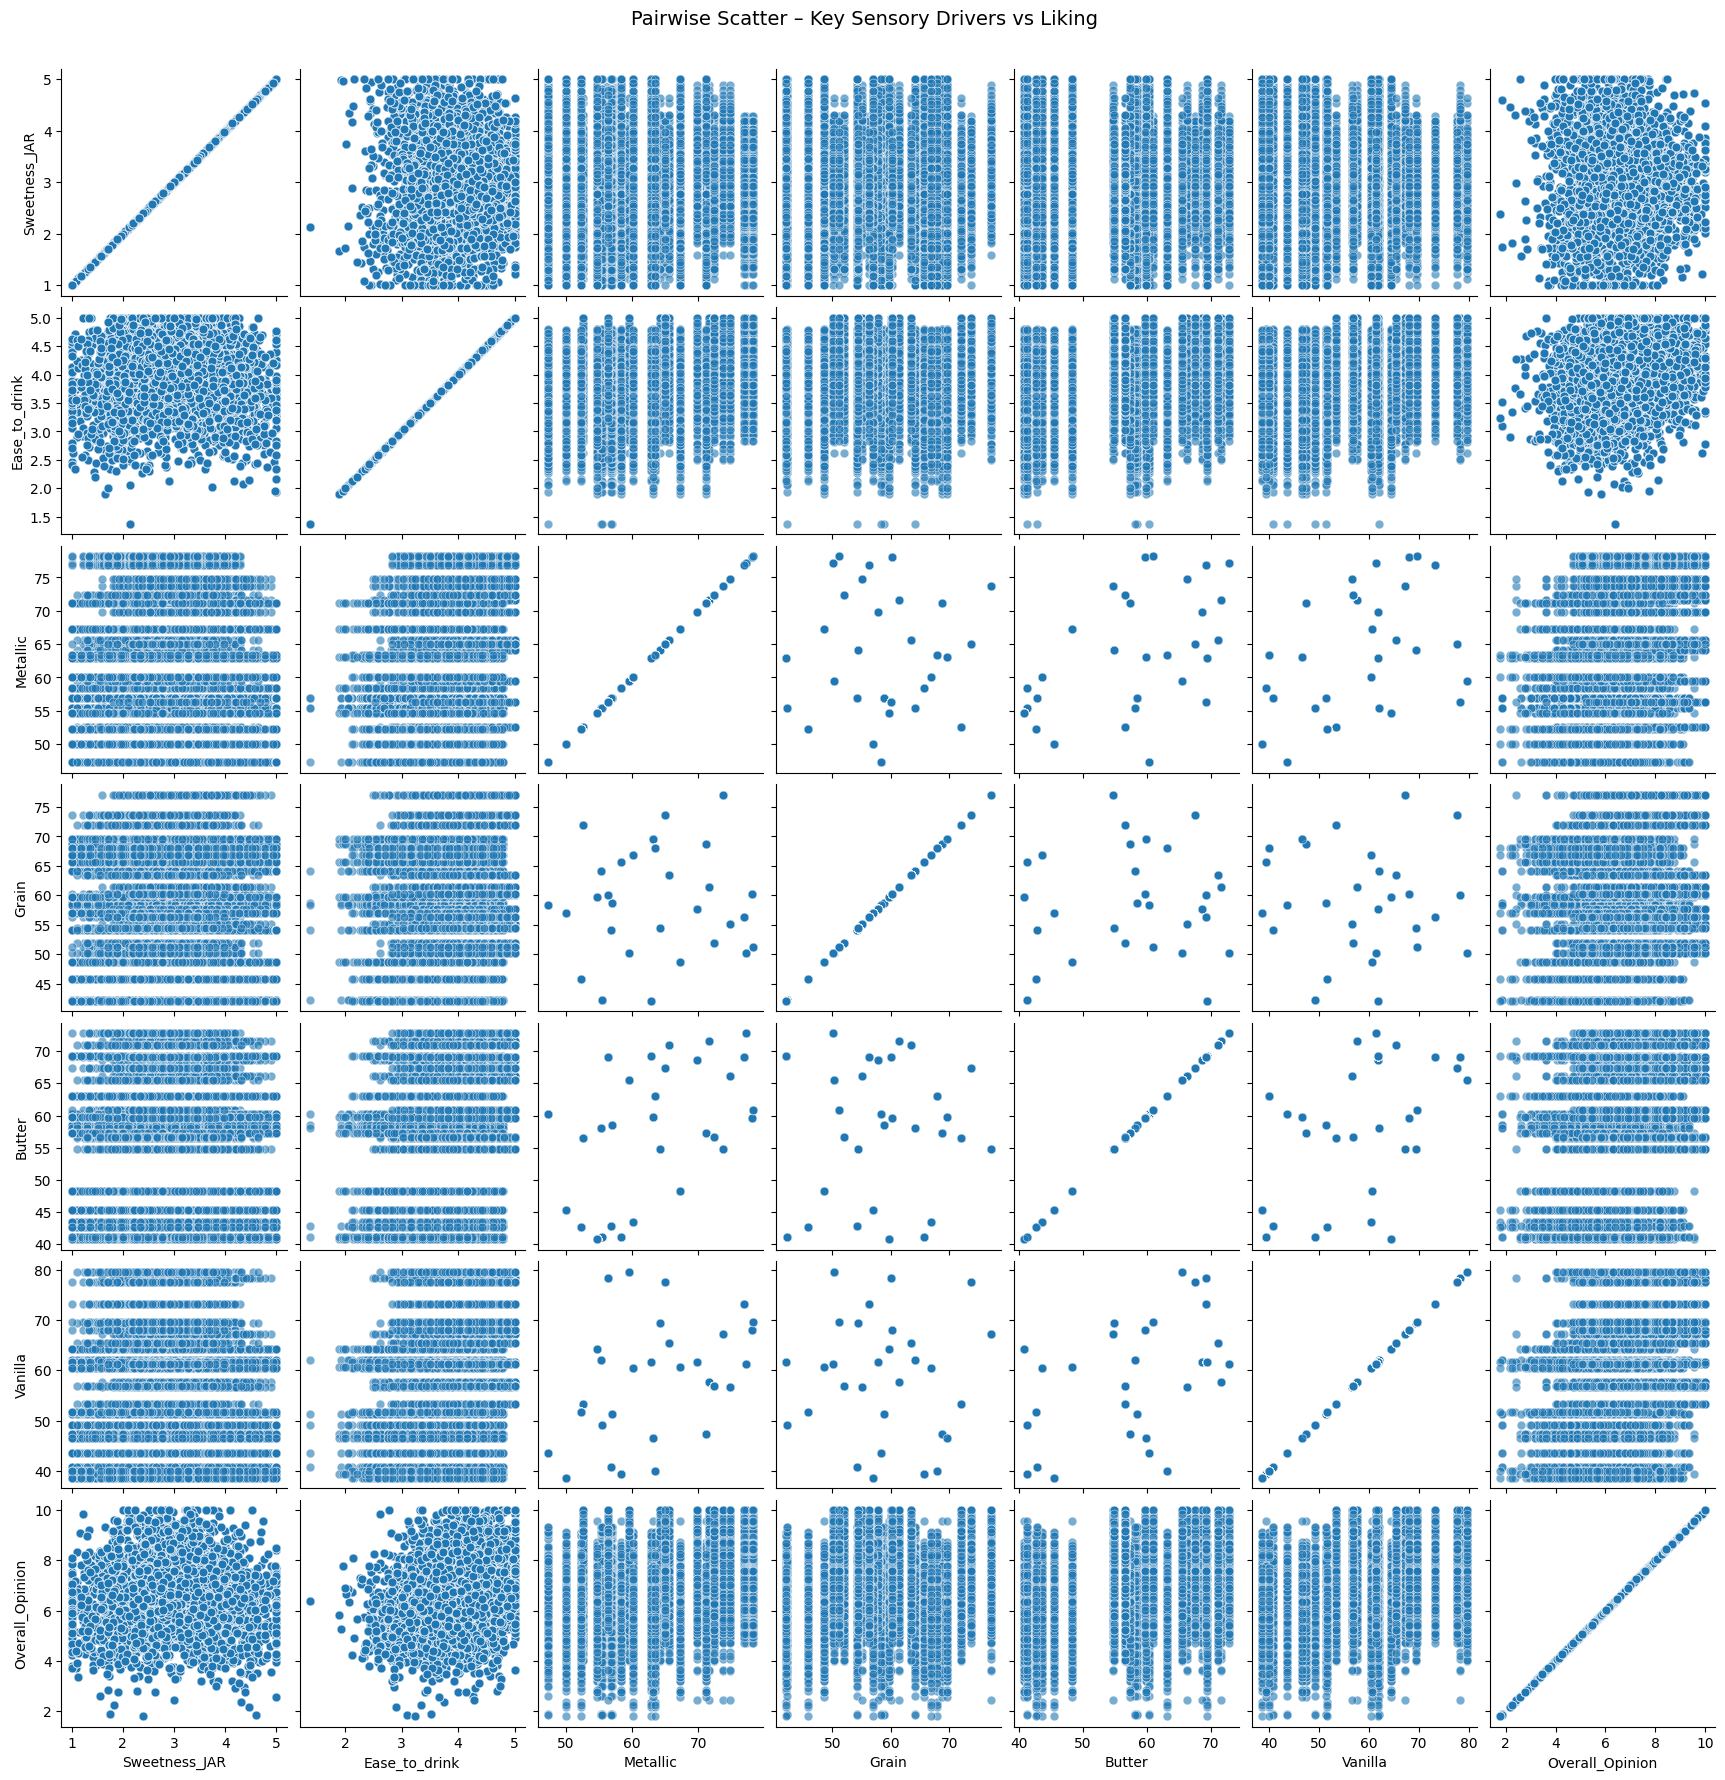

In [ ]:
#no text and ID columns
exclude_cols = ["Open_Text", "Open_Text_clean", "Respondent_ID"]
num_df = data_model.drop(columns=exclude_cols, errors="ignore").select_dtypes(include=["number"])
#Pairwise scatter: selected sensory vs Liking
key_features = ["Sweetness_JAR", "Ease_to_drink", "Metallic", "Grain", "Butter", "Vanilla", "Overall_Opinion"]
sns.pairplot(
    num_df,
    vars=key_features,
    y_vars=["Overall_Opinion"],  #dependent variable
    kind="scatter",
    diag_kind=None,
    plot_kws={"alpha": 0.6, "s": 40, "color": "#1f77b4"}
)
plt.suptitle("Pairwise Scatter – Key Sensory Drivers vs Liking", y=1.02, fontsize=14)
plt.show()

RSI calculation (Relative Superiority Index)

In [ ]:
cols_to_exclude = ["Overall_Opinion", "Open_Text", "Open_Text_clean", "overall_norm", "ease_norm"]
cols_to_exclude = [c for c in cols_to_exclude if c in data.columns]

In [ ]:
rsi = (
    data.groupby(["Market", "Brand"])["Overall_Opinion"]
    .mean()
    .unstack()
    .assign(RSI=lambda df: df["Ours"] - df["Competitor"])
)
print(rsi)

Brand        Competitor      Ours       RSI
Market                                     
France         7.404939  5.912151 -1.492788
Germany        7.349011  5.814658 -1.534352
Netherlands    7.416946  5.970252 -1.446694
Spain          7.335947  5.820676 -1.515271
UK             7.343301  5.975560 -1.367740


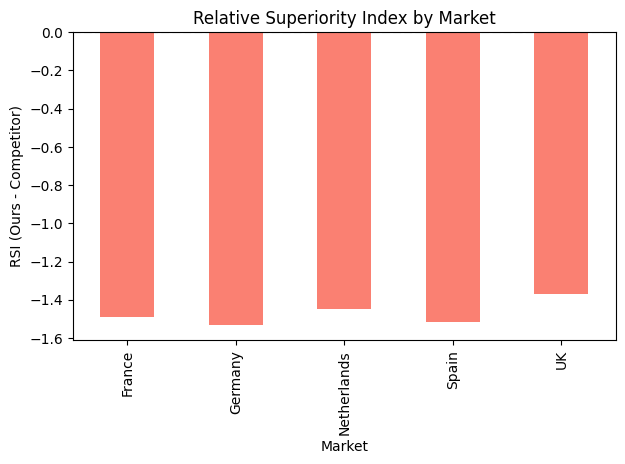

In [ ]:
plt.figure(figsize=(7,4))
rsi["RSI"].plot(kind="bar", color=["salmon" if x < 0 else "seagreen" for x in rsi["RSI"]])
plt.axhline(0, color="gray", linestyle="--")
plt.ylabel("RSI (Ours - Competitor)")
plt.title("Relative Superiority Index by Market")
plt.show()

## Modeling

I chose an XGBoost regression model because it handles complex, non-linear relationships very well and is robust even when multiple factors interact with each other. In our case, the goal is to understand which product attributes drive the overall opinion score, and XGBoost can capture these patterns more accurately than simple linear models.

At the same time, by limiting the tree depth and using a lower learning rate, the model stays interpretable and avoids overfitting. This makes it a good balance between predictive power and explainability, which is important when comparing the drivers behind our brand’s performance versus the competitor.

I built separate models for each brand — one for ours and one for the competitor.
This allows me to clearly see which specific factors drive positive or negative overall opinion within each brand, without the noise that would come from mixing them together.

In [ ]:
results = []
for brand in ["Ours", "Competitor"]:
    subset = data[data["Brand"] == brand]
    X = subset[
        [
            "sweetness_misfit",
            "Sweet_norm",
            "Metallic_norm",
            "Grain_norm",
            "Butter_norm",
            "Vanilla_norm",
            "Milk_norm",
            "ease_norm",
        ]
    ]
    y = subset["overall_norm"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05)
    model.fit(X_train, y_train)
    #evaluation 
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    print(f"\n===== {brand} model =====")
    print(f"RMSE: {rmse:.3f}  |  MAE: {mae:.3f}  |  R²: {r2:.3f}")
    #fi
    fi = (
        pd.DataFrame(
            {"Feature": X.columns, "Importance": model.feature_importances_}
        )
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )
    print("\nTop drivers:")
    print(fi.head(8))
    results.append((brand, fi, rmse, mae, r2))


===== Ours model =====
RMSE: 0.130  |  MAE: 0.103  |  R²: -0.214

Top drivers:
            Feature  Importance
0       Butter_norm    0.146609
1      Vanilla_norm    0.145642
2         Milk_norm    0.140038
3         ease_norm    0.121448
4     Metallic_norm    0.120387
5  sweetness_misfit    0.113024
6        Grain_norm    0.111348
7        Sweet_norm    0.101503

===== Competitor model =====
RMSE: 0.128  |  MAE: 0.104  |  R²: -0.169

Top drivers:
            Feature  Importance
0       Butter_norm    0.129508
1         ease_norm    0.128182
2        Grain_norm    0.127127
3         Milk_norm    0.127022
4      Vanilla_norm    0.124527
5        Sweet_norm    0.123217
6     Metallic_norm    0.120270
7  sweetness_misfit    0.120147


Flavour includeded also 

In [ ]:
results = []
for brand in ["Ours", "Competitor"]:
    subset = data[data["Brand"] == brand].copy()
    flavour_dummies = pd.get_dummies(subset["Flavour"], prefix="Flavour", drop_first=False)
    subset = pd.concat([subset, flavour_dummies], axis=1)
    base_features = [
        "sweetness_misfit",
        "Sweet_norm",
        "Metallic_norm",
        "Grain_norm",
        "Butter_norm",
        "Vanilla_norm",
        "Milk_norm",
        "ease_norm",
    ]
    flavour_cols = list(flavour_dummies.columns)
    X = subset[base_features + flavour_cols]
    y = subset["overall_norm"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    model = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05)
    model.fit(X_train, y_train)
    #validation
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"\n===== {brand} model =====")
    print(f"RMSE: {rmse:.3f}  |  MAE: {mae:.3f}  |  R²: {r2:.3f}")
    #Feature importance
    fi = (
        pd.DataFrame(
            {"Feature": X.columns, "Importance": model.feature_importances_}
        )
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )
    flavour_importance = fi[fi["Feature"].isin(flavour_cols)]["Importance"].sum()
    fi_no_flavour = fi[~fi["Feature"].isin(flavour_cols)].copy()
    fi_no_flavour = pd.concat(
        [
            fi_no_flavour,
            pd.DataFrame([{"Feature": "Flavour", "Importance": flavour_importance}]),
        ],
        ignore_index=True,
    ).sort_values("Importance", ascending=False)
    print("\nTop drivers:")
    print(fi_no_flavour.head(10))
    results.append((brand, fi_no_flavour, rmse, mae, r2))


===== Ours model =====
RMSE: 0.128  |  MAE: 0.101  |  R²: -0.177

Top drivers:
            Feature  Importance
8           Flavour    0.338692
0         Milk_norm    0.107985
1       Butter_norm    0.093019
2         ease_norm    0.086943
3      Vanilla_norm    0.086394
4  sweetness_misfit    0.081386
5     Metallic_norm    0.073553
6        Sweet_norm    0.066806
7        Grain_norm    0.065222

===== Competitor model =====
RMSE: 0.130  |  MAE: 0.105  |  R²: -0.198

Top drivers:
            Feature  Importance
8           Flavour    0.330494
0        Grain_norm    0.098920
1     Metallic_norm    0.085136
2         Milk_norm    0.084653
3       Butter_norm    0.084043
4         ease_norm    0.083718
5  sweetness_misfit    0.081078
6      Vanilla_norm    0.076233
7        Sweet_norm    0.075725


The evaluation metrics are quite poor, but this is expected because we are working with a synthetic dataset and the amount of data is very limited. For this reason, I’m not putting too much weight on the model performance at this stage.

## Model Interpretation / Explainability

## SHAP 

In [ ]:
shap_results = []
for brand, fi in results:
    print(f"\n===== SHAP analysis for {brand} =====")
    subset = data[data["Brand"] == brand]
    X = subset[
        [
            "sweetness_misfit",
            "Sweet_norm",
            "Metallic_norm",
            "Grain_norm",
            "Butter_norm",
            "Vanilla_norm",
            "Milk_norm",
            "ease_norm",
        ]
    ]
    y = subset["overall_norm"]
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    mean_shap = shap_values.mean(axis=0)
    shap_df = pd.DataFrame({
        "Feature": X.columns,
        "Mean_SHAP": mean_shap,
        "Brand": brand
    }).sort_values("Mean_SHAP", ascending=False)
    shap_results.append(shap_df)

    print(f"\nAverage SHAP effect for {brand}:")
    print(shap_df)
    plt.figure(figsize=(6,4))
    plt.barh(shap_df["Feature"], shap_df["Mean_SHAP"],
             color=["#66c2a5" if v>0 else "#fc8d62" for v in shap_df["Mean_SHAP"]])
    plt.title(f"Average SHAP impact on Overall Opinion – {brand}")
    plt.axvline(0, color="black")
    plt.xlabel("Mean SHAP value (positive = increases opinion)")
    plt.show()
    shap.summary_plot(shap_values, X, show=True)

ValueError: too many values to unpack (expected 2)


===== Ours model =====
            Feature  Importance
0         Milk_norm    0.151985
1   Flavour_encoded    0.121024
2       Butter_norm    0.119864
3         ease_norm    0.114958
4      Vanilla_norm    0.112613
5  sweetness_misfit    0.107737
6        Sweet_norm    0.094567
7     Metallic_norm    0.088699
8        Grain_norm    0.088552

Average SHAP effect for Ours (with single Flavour column):
            Feature  Mean_SHAP
7         ease_norm   0.000696
4       Butter_norm   0.000452
8   Flavour_encoded   0.000130
1        Sweet_norm  -0.000087
0  sweetness_misfit  -0.000091
5      Vanilla_norm  -0.000276
6         Milk_norm  -0.000437
3        Grain_norm  -0.000602
2     Metallic_norm  -0.000717


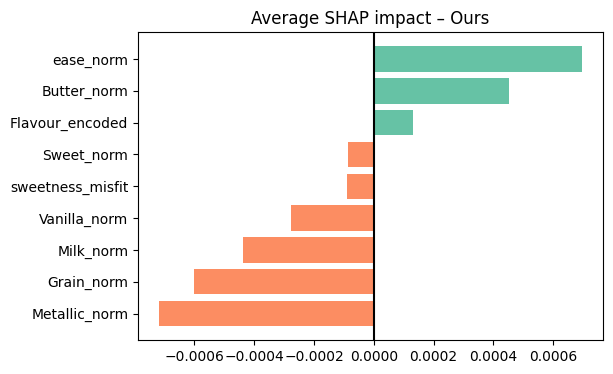

/var/folders/9z/jnfn6k6j6nd7xchr2fbndyk80000gn/T/ipykernel_45584/1613367052.py:57: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=True)


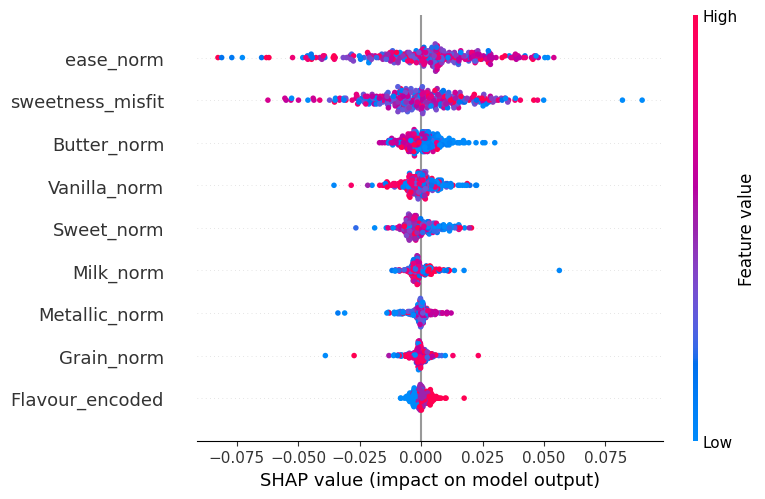


===== Competitor model =====
            Feature  Importance
0        Grain_norm    0.130332
1         ease_norm    0.114202
2   Flavour_encoded    0.110652
3     Metallic_norm    0.109818
4         Milk_norm    0.108878
5  sweetness_misfit    0.108624
6        Sweet_norm    0.106710
7      Vanilla_norm    0.106343
8       Butter_norm    0.104441

Average SHAP effect for Competitor (with single Flavour column):
            Feature  Mean_SHAP
0  sweetness_misfit   0.001307
5      Vanilla_norm   0.000353
7         ease_norm   0.000266
8   Flavour_encoded  -0.000030
6         Milk_norm  -0.000129
3        Grain_norm  -0.000277
2     Metallic_norm  -0.000279
4       Butter_norm  -0.000322
1        Sweet_norm  -0.001643


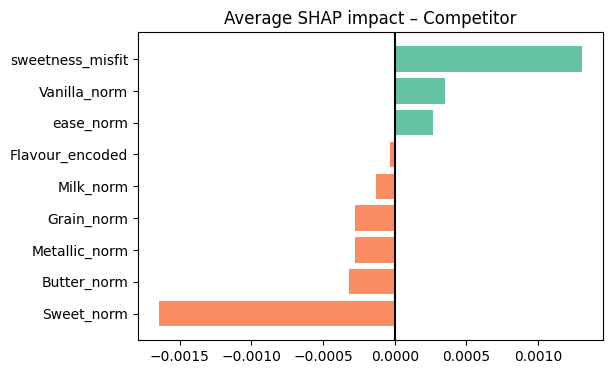

/var/folders/9z/jnfn6k6j6nd7xchr2fbndyk80000gn/T/ipykernel_45584/1613367052.py:57: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=True)


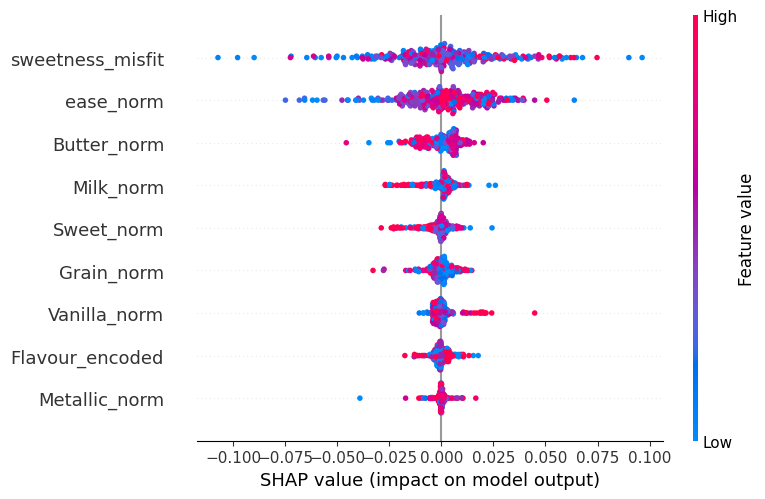

In [ ]:
results = []
fl_enc = LabelEncoder()
fl_enc.fit(data["Flavour"])   # Vanilla / Strawberry / Chocolate

for brand in ["Ours", "Competitor"]:
    subset = data[data["Brand"] == brand].copy()
    subset["Flavour_encoded"] = fl_enc.transform(subset["Flavour"])
    X = subset[
        [
            "sweetness_misfit",
            "Sweet_norm",
            "Metallic_norm",
            "Grain_norm",
            "Butter_norm",
            "Vanilla_norm",
            "Milk_norm",
            "ease_norm",
            "Flavour_encoded",  
        ]
    ]
    y = subset["overall_norm"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    model = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
    model.fit(X_train, y_train)
    fi = (
        pd.DataFrame(
            {"Feature": X.columns, "Importance": model.feature_importances_}
        )
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )
    results.append((brand, fi))
    print(f"\n===== {brand} model =====")
    print(fi)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    mean_shap = shap_values.mean(axis=0)
    shap_df = pd.DataFrame({
        "Feature": X.columns,
        "Mean_SHAP": mean_shap,
    }).sort_values("Mean_SHAP", ascending=False)
    print(f"\nAverage SHAP effect for {brand} (with single Flavour column):")
    print(shap_df)
    plt.figure(figsize=(6,4))
    plt.barh(
        shap_df["Feature"],
        shap_df["Mean_SHAP"],
        color=["#66c2a5" if v > 0 else "#fc8d62" for v in shap_df["Mean_SHAP"]],
    )
    plt.title(f"Average SHAP impact – {brand}")
    plt.axvline(0, color="black")
    plt.gca().invert_yaxis()
    plt.show()

    shap.summary_plot(shap_values, X_test, show=True)

## Feature Importance Market

In [ ]:
market_results = []
for market in data["Market"].unique():
    print(f"\n Market: {market}")
    subset = data[data["Market"] == market]
    X = subset[
        [
            "sweetness_misfit",
            "Sweet_norm",
            "Metallic_norm",
            "Grain_norm",
            "Butter_norm",
            "Vanilla_norm",
            "Milk_norm",
            "ease_norm",
        ]
    ]
    y = subset["overall_norm"]
    model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05)
    model.fit(X, y)
    fi = pd.DataFrame(
        {"Feature": X.columns, "Importance": model.feature_importances_}
    ).sort_values("Importance", ascending=False)
    print(fi.head(5))
    fi["Market"] = market  
    market_results.append(fi)  
market_importances = pd.concat(market_results, ignore_index=True)


 Market: Netherlands
            Feature  Importance
5      Vanilla_norm    0.633162
4       Butter_norm    0.095525
6         Milk_norm    0.084810
0  sweetness_misfit    0.045048
7         ease_norm    0.042855

 Market: France
         Feature  Importance
1     Sweet_norm    0.666651
6      Milk_norm    0.072115
2  Metallic_norm    0.055649
5   Vanilla_norm    0.054515
7      ease_norm    0.047925

 Market: UK
            Feature  Importance
5      Vanilla_norm    0.846355
4       Butter_norm    0.041020
7         ease_norm    0.031465
3        Grain_norm    0.031145
0  sweetness_misfit    0.027562

 Market: Germany
            Feature  Importance
3        Grain_norm    0.832989
0  sweetness_misfit    0.035869
1        Sweet_norm    0.032934
7         ease_norm    0.028681
2     Metallic_norm    0.027015

 Market: Spain
            Feature  Importance
2     Metallic_norm    0.754327
5      Vanilla_norm    0.090973
3        Grain_norm    0.047377
7         ease_norm    0.038855
0  s

With Flavour

In [ ]:
fl_enc = LabelEncoder()
fl_enc.fit(data["Flavour"])
data["Flavour_encoded"] = fl_enc.transform(data["Flavour"])
market_results = [] 
for market in data["Market"].unique():
    print(f"\n Market: {market}")
    subset = data[data["Market"] == market].copy()
    X = subset[
        [
            "sweetness_misfit",
            "Sweet_norm",
            "Metallic_norm",
            "Grain_norm",
            "Butter_norm",
            "Vanilla_norm",
            "Milk_norm",
            "ease_norm",
            "Flavour_encoded",
        ]
    ]
    y = subset["overall_norm"]
    # XGBoost modell
    model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
    model.fit(X, y)
    #feature importance
    fi = (
        pd.DataFrame(
            {"Feature": X.columns, "Importance": model.feature_importances_}
        )
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )
    print(fi.head(6))
    fi["Market"] = market
    market_results.append(fi)
market_importances = pd.concat(market_results, ignore_index=True)
flavour_impact = (
    market_importances[market_importances["Feature"] == "Flavour_encoded"]
    .sort_values("Importance", ascending=False)
)
print("\n=== Flavour importance by market ===")
print(flavour_impact)


 Market: Netherlands
            Feature  Importance
0      Vanilla_norm    0.614461
1       Butter_norm    0.082339
2         Milk_norm    0.074513
3   Flavour_encoded    0.067476
4  sweetness_misfit    0.039708
5         ease_norm    0.037763

 Market: France
            Feature  Importance
0        Sweet_norm    0.644322
1         Milk_norm    0.069576
2     Metallic_norm    0.056193
3      Vanilla_norm    0.050898
4  sweetness_misfit    0.046437
5         ease_norm    0.046108

 Market: UK
            Feature  Importance
0      Vanilla_norm    0.822903
1       Butter_norm    0.036718
2        Grain_norm    0.032239
3   Flavour_encoded    0.030331
4         ease_norm    0.030325
5  sweetness_misfit    0.026708

 Market: Germany
            Feature  Importance
0        Grain_norm    0.814621
1  sweetness_misfit    0.034591
2        Sweet_norm    0.033233
3         Milk_norm    0.031706
4         ease_norm    0.028428
5     Metallic_norm    0.026190

 Market: Spain
            Featur


 Market: Netherlands
            Feature  Importance
0      Vanilla_norm    0.614461
1       Butter_norm    0.082339
2         Milk_norm    0.074513
3   Flavour_encoded    0.067476
4  sweetness_misfit    0.039708
5         ease_norm    0.037763

 Market: France
            Feature  Importance
0        Sweet_norm    0.644322
1         Milk_norm    0.069576
2     Metallic_norm    0.056193
3      Vanilla_norm    0.050898
4  sweetness_misfit    0.046437
5         ease_norm    0.046108

 Market: UK
            Feature  Importance
0      Vanilla_norm    0.822903
1       Butter_norm    0.036718
2        Grain_norm    0.032239
3   Flavour_encoded    0.030331
4         ease_norm    0.030325
5  sweetness_misfit    0.026708

 Market: Germany
            Feature  Importance
0        Grain_norm    0.814621
1  sweetness_misfit    0.034591
2        Sweet_norm    0.033233
3         Milk_norm    0.031706
4         ease_norm    0.028428
5     Metallic_norm    0.026190

 Market: Spain
            Featur

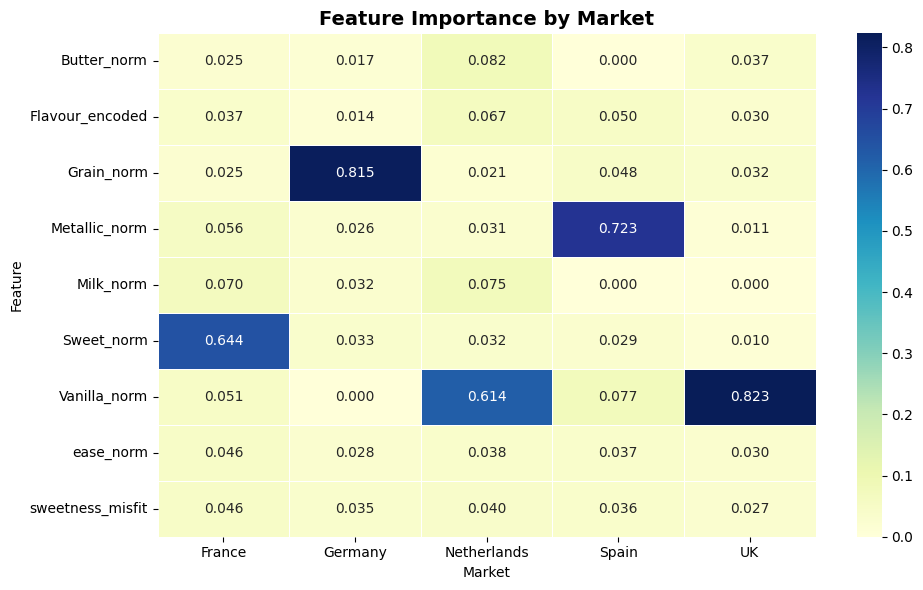

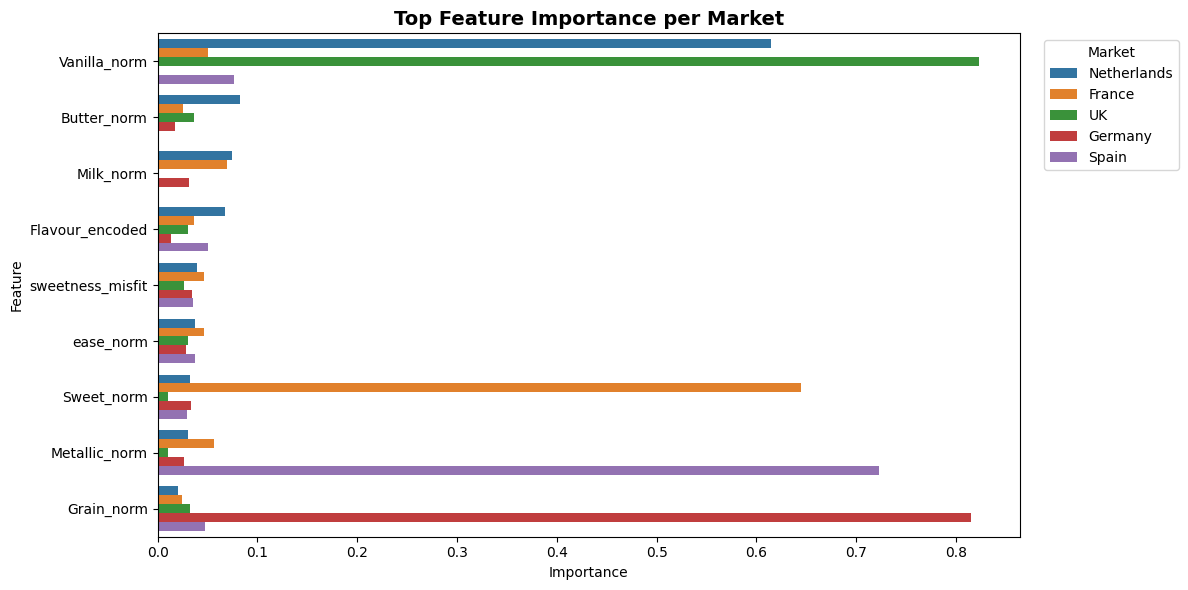

In [ ]:
fl_enc = LabelEncoder()
fl_enc.fit(data["Flavour"])
data["Flavour_encoded"] = fl_enc.transform(data["Flavour"])
market_results = []
for market in data["Market"].unique():
    print(f"\n Market: {market}")
    subset = data[data["Market"] == market].copy()
    X = subset[
        [
            "sweetness_misfit",
            "Sweet_norm",
            "Metallic_norm",
            "Grain_norm",
            "Butter_norm",
            "Vanilla_norm",
            "Milk_norm",
            "ease_norm",
            "Flavour_encoded",
        ]
    ]
    y = subset["overall_norm"]
    model = XGBRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42
    )
    model.fit(X, y)
    fi = (
        pd.DataFrame(
            {"Feature": X.columns, "Importance": model.feature_importances_}
        )
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )
    print(fi.head(6))
    fi["Market"] = market
    market_results.append(fi)
market_importances = pd.concat(market_results, ignore_index=True)
pivot = market_importances.pivot(
    index="Feature", columns="Market", values="Importance"
)
plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot,
    annot=True,
    cmap="YlGnBu",
    fmt=".3f",
    linewidths=0.5,
    linecolor="white",
)
plt.title("Feature Importance by Market", fontsize=14, weight="bold")
plt.xlabel("Market")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 6))
sns.barplot(
    data=market_importances,
    x="Importance",
    y="Feature",
    hue="Market",
    dodge=True,
)
plt.title("Top Feature Importance per Market", fontsize=14, weight="bold")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.legend(title="Market", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Market x Brand


=== Flavour importance by Market & Brand ===
            Feature  Importance       Market       Brand
35  Flavour_encoded         0.0       France  Competitor
26  Flavour_encoded         0.0       France        Ours
71  Flavour_encoded         0.0      Germany  Competitor
62  Flavour_encoded         0.0      Germany        Ours
17  Flavour_encoded         0.0  Netherlands  Competitor
8   Flavour_encoded         0.0  Netherlands        Ours
89  Flavour_encoded         0.0        Spain  Competitor
80  Flavour_encoded         0.0        Spain        Ours
53  Flavour_encoded         0.0           UK  Competitor
44  Flavour_encoded         0.0           UK        Ours


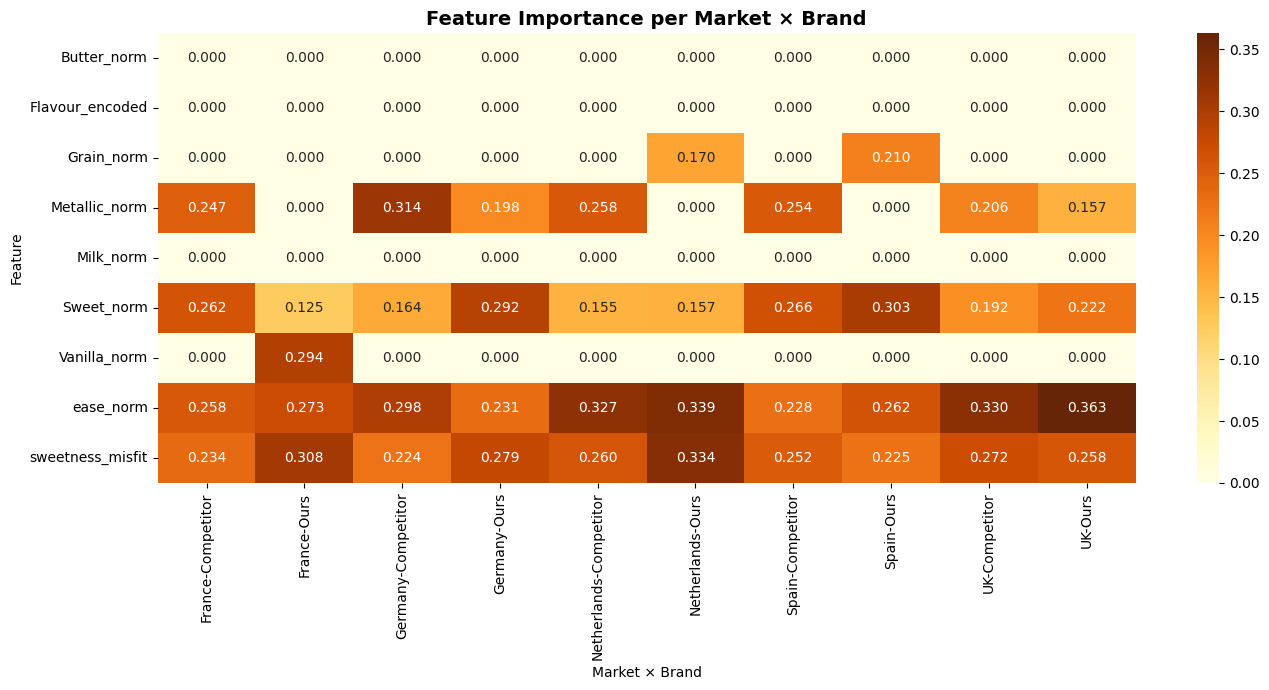

In [ ]:
fl_enc = LabelEncoder()
fl_enc.fit(data["Flavour"])
data["Flavour_encoded"] = fl_enc.transform(data["Flavour"])
results = []
for market in data["Market"].unique():
    for brand in ["Ours", "Competitor"]:
        subset = data[(data["Market"] == market) & (data["Brand"] == brand)].copy()
        if len(subset) < 10:
            continue
        X = subset[
            [
                "sweetness_misfit",
                "Sweet_norm",
                "Metallic_norm",
                "Grain_norm",
                "Butter_norm",
                "Vanilla_norm",
                "Milk_norm",
                "ease_norm",
                "Flavour_encoded",  
            ]
        ]
        y = subset["overall_norm"]
        model = XGBRegressor(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.05,
            random_state=42,
        )
        model.fit(X, y)
        fi = (
            pd.DataFrame(
                {
                    "Feature": X.columns,
                    "Importance": model.feature_importances_,
                }
            )
            .sort_values("Importance", ascending=False)
            .reset_index(drop=True)
        )
        fi["Market"] = market
        fi["Brand"] = brand

        results.append(fi)
comparison_importances = pd.concat(results, ignore_index=True)
flavour_impact = (
    comparison_importances[comparison_importances["Feature"] == "Flavour_encoded"]
    .sort_values(["Market", "Brand"])
)
print("\n=== Flavour importance by Market & Brand ===")
print(flavour_impact)
#heatmap
pivot = comparison_importances.pivot_table(
    index="Feature",
    columns=["Market", "Brand"],
    values="Importance",
)
plt.figure(figsize=(14, 7))
sns.heatmap(pivot, annot=True, cmap="YlOrBr", fmt=".3f")
plt.title("Feature Importance per Market × Brand", fontsize=14, weight="bold")
plt.xlabel("Market × Brand")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

/var/folders/9z/jnfn6k6j6nd7xchr2fbndyk80000gn/T/ipykernel_45584/2632659863.py:42: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/envs/ux_case_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


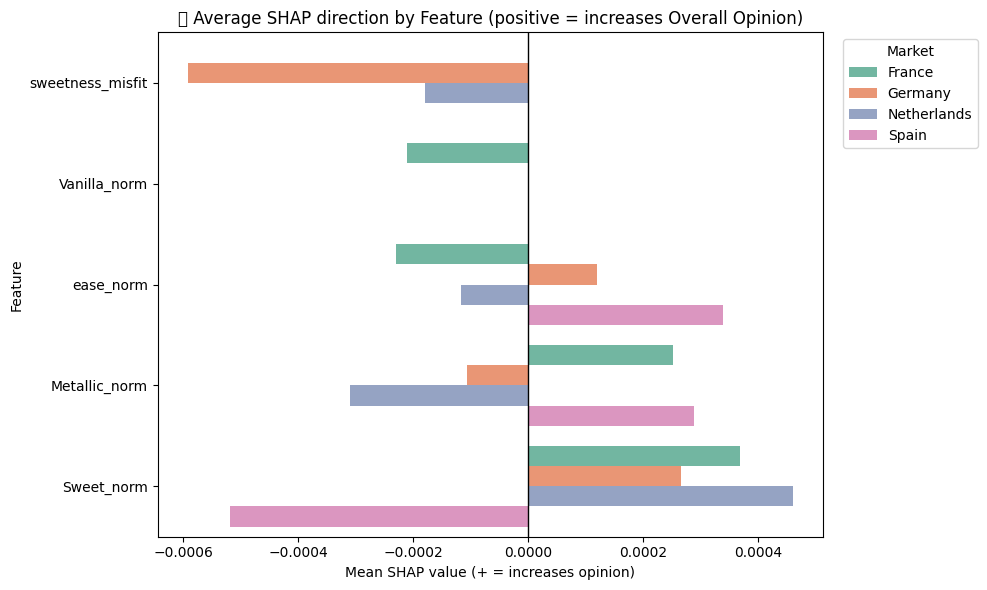

In [ ]:
market_avg = (
    shap_all.groupby(["Market", "Feature"])["Mean_SHAP"]
    .mean()
    .reset_index()
)
market_avg = market_avg[market_avg["Mean_SHAP"].abs() > 0.0001]
feature_order = (
    market_avg.groupby("Feature")["Mean_SHAP"]
    .mean()
    .sort_values()
    .index
)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=market_avg,
    x="Mean_SHAP",
    y="Feature",
    hue="Market",
    dodge=True,
    errorbar=None,
    order=feature_order,
    palette="Set2"
)
plt.axvline(0, color="black", linewidth=1)
plt.title("🌍 Average SHAP direction by Feature (positive = increases Overall Opinion)")
plt.xlabel("Mean SHAP value (+ = increases opinion)")
plt.ylabel("Feature")
plt.legend(title="Market", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
subset = data.copy()
subset["Flavour"] = subset["Flavour"].astype("category")
subset["Market"] = subset["Market"].astype("category")
subset["Brand"] = subset["Brand"].astype("category")

After training the XGBoost model, I also ran a mixed-effects linear model as a statistical validation step to confirm which drivers are consistently significant across markets. This gives interpretable coefficients and p-values, ensuring that the insights are not only model-driven but also statistically robust.

MixedML

In [ ]:
data["overall_norm"] = data["Overall_Opinion"] / 10.0
data["ease_norm"] = data["Ease_to_drink"] / 5.0
data["sweetness_misfit"] = (data["Sweetness_JAR"] - 3).abs()
sensory_cols = ["Sweet", "Metallic", "Grain", "Butter", "Vanilla", "Milk"]
for col in sensory_cols:
    data[col + "_norm"] = data[col] / 100.0

In [ ]:
model = smf.mixedlm(
    "overall_norm ~ ease_norm + sweetness_misfit + Sweet_norm + Metallic_norm",
    data=data,
    groups=data["Market"],
    re_formula="~ease_norm"
)
result = model.fit()
print(result.summary())

##valid\evaluation for the mixed model
#predicted values and residuals
y_true = data["overall_norm"]
y_pred = result.fittedvalues
residuals = y_true - y_pred
#RMSE and Rsquare
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
print("\nModel evaluation:")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")
print(f"\nMean residual: {np.mean(residuals):.4f}")
print(f"Residual std:  {np.std(residuals):.4f}")

             Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   overall_norm
No. Observations:   3000      Method:               REML        
No. Groups:         5         Scale:                0.0167      
Min. group size:    600       Log-Likelihood:       1849.5840   
Max. group size:    600       Converged:            No          
Mean group size:    600.0                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.157    0.041  3.838 0.000  0.077  0.237
ease_norm              0.134    0.037  3.594 0.000  0.061  0.208
sweetness_misfit      -0.034    0.005 -7.078 0.000 -0.043 -0.025
Sweet_norm             0.270    0.038  7.189 0.000  0.196  0.344
Metallic_norm          0.406    0.030 13.554 0.000  0.347  0.465
Group Var              0.004    0.023  

/opt/anaconda3/envs/ux_case_env/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/ux_case_env/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/envs/ux_case_env/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/ux_case_env/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/opt/anaconda3/envs/ux_case_env/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimi

Again, the valiadation is not ideal but this is just a mock data

In [ ]:
re = result.random_effects 
re_df = (
    pd.DataFrame(re)
    .T
    .reset_index()
    .rename(columns={"index": "Market"})
)
print(re_df)

        Market     Group  ease_norm
0       France  0.005977   0.008492
1      Germany -0.031491   0.006988
2  Netherlands  0.016975   0.010472
3        Spain -0.017410   0.005653
4           UK  0.025949  -0.031605


## Sentiment Analysis

In [ ]:
analyzer = SentimentIntensityAnalyzer()
data["sentiment"] = data["Open_Text_clean"].fillna("").apply(
    lambda txt: analyzer.polarity_scores(txt)["compound"]
)
print(data["sentiment"].describe())

KeyError: 'Open_Text_clean'

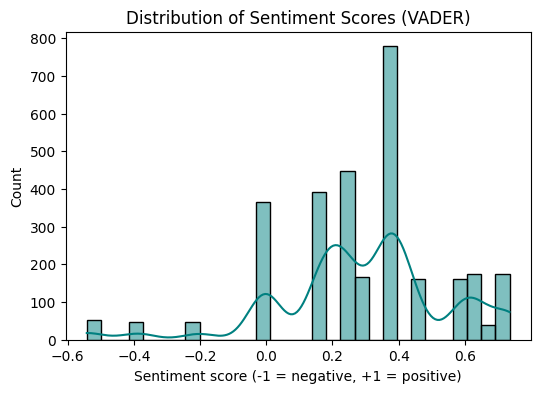

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(data["sentiment"], bins=30, kde=True, color="teal")
plt.title("Distribution of Sentiment Scores (VADER)")
plt.xlabel("Sentiment score (-1 = negative, +1 = positive)")
plt.ylabel("Count")
plt.show()

In [ ]:
corr = data[["sentiment", "overall_norm"]].corr().iloc[0,1]
print(f"Correlation sentiment ↔ overall_norm: {corr:.2f}")

Correlation sentiment ↔ overall_norm: 0.56


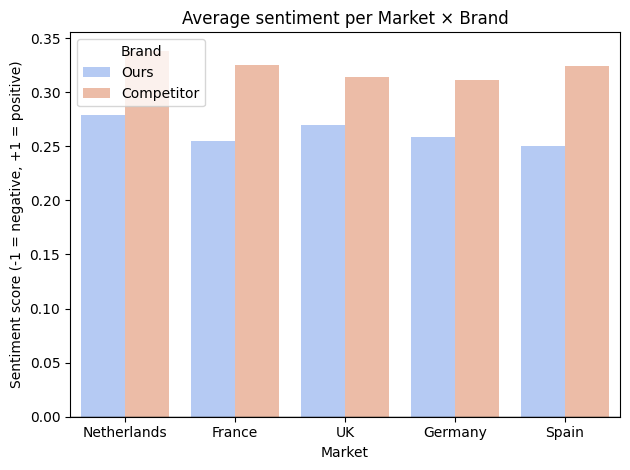

In [ ]:
sns.barplot(
    data=data,
    x="Market", y="sentiment", hue="Brand",
    palette="coolwarm",
    errorbar=None  # ⬅️ ez eltünteti a vonalakat
)
plt.title("Average sentiment per Market × Brand")
plt.axhline(0, color="black", linewidth=1)
plt.ylabel("Sentiment score (-1 = negative, +1 = positive)")
plt.tight_layout()
plt.show()

In [ ]:
avg_sentiment = data.groupby(["Market", "Brand"])["sentiment"].mean().unstack()
rsi["Sentiment_gap"] = avg_sentiment["Ours"] - avg_sentiment["Competitor"]
print(rsi[["RSI", "Sentiment_gap"]])

Brand             RSI  Sentiment_gap
Market                              
France      -1.492788      -0.070373
Germany     -1.534352      -0.053159
Netherlands -1.446694      -0.059826
Spain       -1.515271      -0.073692
UK          -1.367740      -0.044099


In [ ]:
features = [
    "sweetness_misfit", "Sweet_norm", "Metallic_norm",
    "Grain_norm", "Butter_norm", "Vanilla_norm",
    "Milk_norm", "ease_norm"
]
corrs = data[features + ["sentiment"]].corr()["sentiment"].sort_values(ascending=False)
print(corrs)

sentiment           1.000000
Milk_norm           0.093622
Vanilla_norm        0.080296
Butter_norm         0.080099
Metallic_norm       0.071787
ease_norm           0.024471
Grain_norm          0.020972
Sweet_norm          0.019298
sweetness_misfit   -0.050155
Name: sentiment, dtype: float64


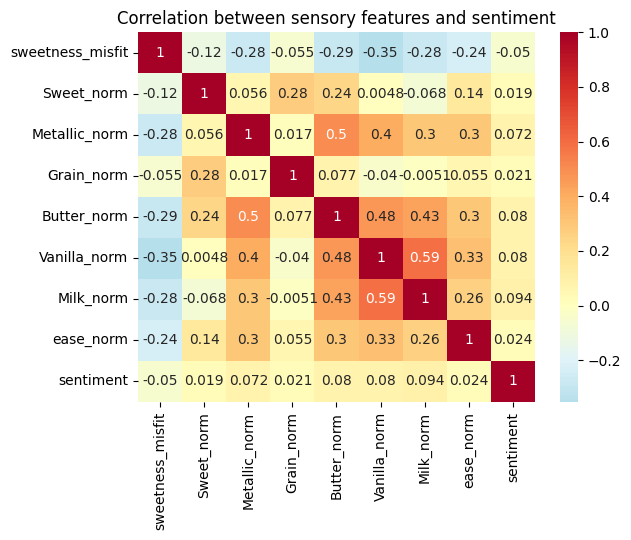

In [ ]:
sns.heatmap(data[features + ["sentiment"]].corr(), annot=True, cmap="RdYlBu_r", center=0)
plt.title("Correlation between sensory features and sentiment")
plt.show()

In [ ]:
X = data[[
    "sweetness_misfit", "Sweet_norm", "Metallic_norm",
    "Grain_norm", "Butter_norm", "Vanilla_norm",
    "Milk_norm", "ease_norm"
]]
y = data["sentiment"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05)
model.fit(X_train, y_train)
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)
print(importances)

            Feature  Importance
4       Butter_norm    0.135576
2     Metallic_norm    0.134918
6         Milk_norm    0.131366
3        Grain_norm    0.130121
7         ease_norm    0.123882
5      Vanilla_norm    0.123565
1        Sweet_norm    0.115560
0  sweetness_misfit    0.105012


Modeling:Feature Engineering / Representation Learning (TF-IDF + numeric merge)

For the text and numeric data, I built a combined sklearn pipeline: a TF–IDF vectorizer for open-text responses, a ColumnTransformer to merge text and sensory features, and an XGBoost regressor on top. This ensures consistent preprocessing and makes the model easy to validate and deploy

Pipeline repreentation

In [189]:
#text + numeric
text_col = "Open_Text_clean"
num_cols = [
    "sweetness_misfit", "Sweet_norm", "Metallic_norm",
    "Grain_norm", "Butter_norm", "Vanilla_norm",
    "Milk_norm", "ease_norm"
]
#TF-IDF transformer
tfidf = TfidfVectorizer(max_features=500, stop_words='english')
ct = ColumnTransformer([
    ("tfidf", tfidf, text_col),
    ("num", "passthrough", num_cols)
])
model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4)
pipe = Pipeline([
    ("pre", ct),
    ("model", model)
])
X_train, X_test, y_train, y_test = train_test_split(
    data[[text_col] + num_cols],
    data["overall_norm"],
    test_size=0.2,
    random_state=42
)
pipe.fit(X_train, y_train) ##for pipeline representation

,steps,"[('pre', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tfidf', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [188]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(data["Open_Text_clean"].fillna(""))
#add it to numeric features
X = np.hstack([embeddings, data[num_cols].values])
y = data["overall_norm"]

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(data["Open_Text_clean"].fillna(""), show_progress_bar=True)

Batches: 100%|██████████| 94/94 [00:01<00:00, 51.87it/s]


In [ ]:
embeddings_df = pd.DataFrame(embeddings)
print(embeddings_df.shape)
embeddings_df.head()

(3000, 384)


,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
0,-0.047301,-0.129025,0.035065,0.011572,-0.066478,-0.018056,0.049857,0.056049,0.016022,-0.032087,...,0.010989,-0.026716,-0.003768,0.006286,-0.039828,-0.051095,0.135761,-0.058326,-0.017904,-0.071217
1,-0.097100,-0.058013,-0.047842,-0.020254,-0.090796,-0.036406,0.054836,0.060623,-0.025697,-0.056589,...,0.105137,-0.064414,-0.027611,-0.055245,-0.041766,0.008245,0.064532,0.030003,-0.000650,-0.006466
2,-0.020851,-0.014359,-0.002729,0.034562,-0.062635,0.002561,0.070295,0.028829,-0.052049,-0.053377,...,0.062074,-0.073054,0.015195,-0.003237,-0.023990,-0.099713,0.063285,0.016601,-0.022426,-0.045419
3,-0.036949,-0.107522,0.034479,0.054591,-0.033101,-0.052685,0.034508,0.022117,-0.043853,-0.044309,...,0.027897,-0.072210,0.014105,0.046832,-0.040519,0.020211,0.103779,-0.044208,-0.090787,-0.058165
4,-0.074170,0.003176,0.017458,0.051437,0.094697,0.042922,0.090741,0.045901,0.008285,-0.047907,...,0.019999,-0.060641,-0.037021,-0.033283,0.048831,-0.088145,-0.020589,0.069708,0.102933,-0.048358


reduce the 384-dimensional embeddings to 2 dimensions

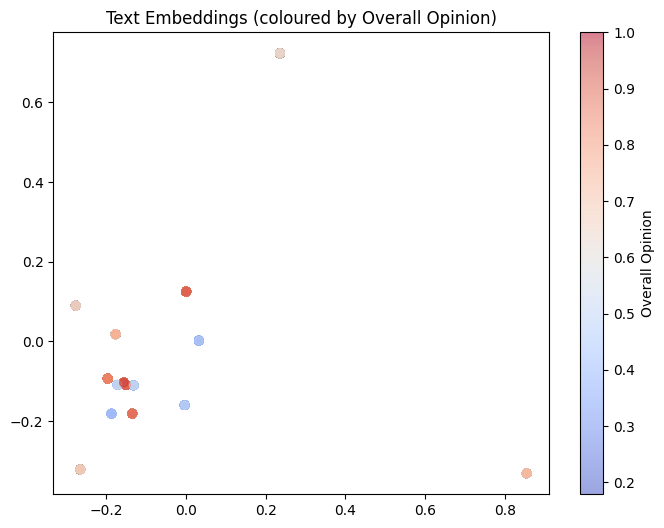

In [ ]:
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(8,6))
plt.scatter(emb_2d[:,0], emb_2d[:,1], alpha=0.5, c=data["overall_norm"], cmap="coolwarm")
plt.colorbar(label="Overall Opinion")
plt.title("Text Embeddings (coloured by Overall Opinion)")
plt.show()

In [ ]:
#merge them
num_features = [
    "sweetness_misfit", "Sweet_norm", "Metallic_norm",
    "Grain_norm", "Butter_norm", "Vanilla_norm",
    "Milk_norm", "ease_norm"
]
X = np.hstack([data[num_features].values, embeddings])
y = data["overall_norm"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4)
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
num_features = [
    "sweetness_misfit", "Sweet_norm", "Metallic_norm",
    "Grain_norm", "Butter_norm", "Vanilla_norm",
    "Milk_norm", "ease_norm"
]
X_num = data[num_features].values
y = data["overall_norm"]
X_train_num, X_test_num, y_train, y_test = train_test_split(
    X_num, y, test_size=0.2, random_state=42
)
model_num = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4)
model_num.fit(X_train_num, y_train)
#num plus embeddings
X_full = np.hstack([data[num_features].values, embeddings])
X_train_full, X_test_full, _, _ = train_test_split(
    X_full, y, test_size=0.2, random_state=42
)
model_full = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4)
model_full.fit(X_train_full, y_train)
#compare
y_pred_num = model_num.predict(X_test_num)
y_pred_full = model_full.predict(X_test_full)
r2_num = r2_score(y_test, y_pred_num)
r2_full = r2_score(y_test, y_pred_full)
print(f"Numeric only R²: {r2_num:.3f}")
print(f"With text embeddings R²: {r2_full:.3f}")
print(f"Improvement: {(r2_full - r2_num)*100:.2f}%")

Numeric only R²: 0.212
With text embeddings R²: 0.766
Improvement: 55.41%


SHAP

/var/folders/9z/jnfn6k6j6nd7xchr2fbndyk80000gn/T/ipykernel_45584/103494034.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="Feature", x="Mean_SHAP", data=shap_importance, palette="viridis")


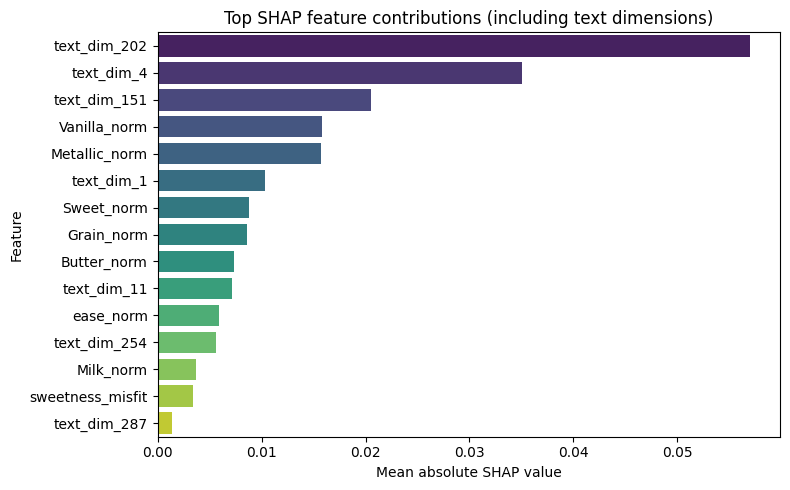

In [ ]:
explainer = shap.TreeExplainer(model_full)
shap_values = explainer.shap_values(X_test_full)
mean_shap = np.abs(shap_values).mean(axis=0)
feature_names = num_features + [f"text_dim_{i}" for i in range(embeddings.shape[1])]
shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_SHAP": mean_shap
}).sort_values("Mean_SHAP", ascending=False).head(15)
plt.figure(figsize=(8,5))
sns.barplot(y="Feature", x="Mean_SHAP", data=shap_importance, palette="viridis")
plt.title("Top SHAP feature contributions (including text dimensions)")
plt.xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()

/var/folders/9z/jnfn6k6j6nd7xchr2fbndyk80000gn/T/ipykernel_45584/103494034.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="Feature", x="Mean_SHAP", data=shap_importance, palette="viridis")


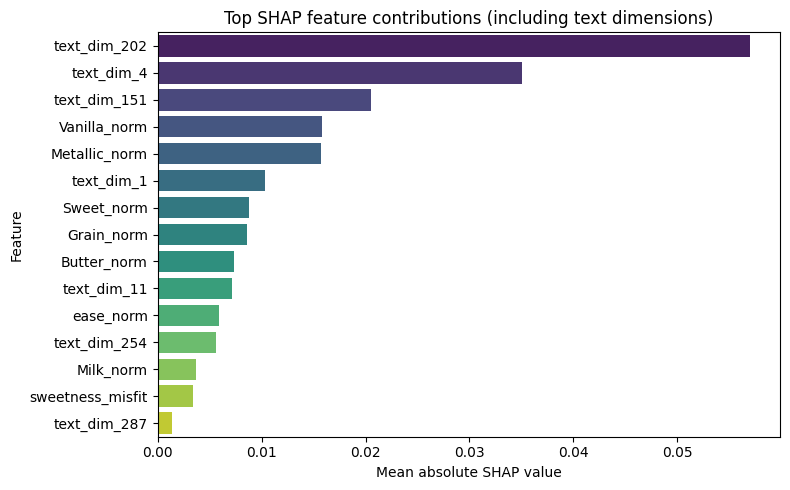

In [ ]:
explainer = shap.TreeExplainer(model_full)
shap_values = explainer.shap_values(X_test_full)
mean_shap = np.abs(shap_values).mean(axis=0)
feature_names = num_features + [f"text_dim_{i}" for i in range(embeddings.shape[1])]
shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_SHAP": mean_shap
}).sort_values("Mean_SHAP", ascending=False).head(15)
plt.figure(figsize=(8,5))
sns.barplot(y="Feature", x="Mean_SHAP", data=shap_importance, palette="viridis")
plt.title("Top SHAP feature contributions (including text dimensions)")
plt.xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()

In [191]:
emb_df = pd.DataFrame(embeddings, index=data.index)
emb_df.columns = [f"text_dim_{i}" for i in range(emb_df.shape[1])]
data = pd.concat([data, emb_df], axis=1)

In [192]:
shap_importance

,Feature,Mean_SHAP
210,text_dim_202,0.057023
12,text_dim_4,0.035038
159,text_dim_151,0.020552
5,Vanilla_norm,0.015819
2,Metallic_norm,0.015742
9,text_dim_1,0.010354
1,Sweet_norm,0.008825
3,Grain_norm,0.008579
4,Butter_norm,0.007384
19,text_dim_11,0.007199


In [193]:
top_text_dims = (
    shap_importance[shap_importance["Feature"].str.startswith("text_dim_")]
    .head(5)["Feature"]
    .tolist()
)

In [194]:
top_text_dims = (
    shap_importance[shap_importance["Feature"].str.startswith("text_dim_")]
    .head(5)["Feature"]
    .tolist()
)
tfidf = TfidfVectorizer(max_features=300, stop_words="english")
X_tfidf = tfidf.fit_transform(data["Open_Text_clean"].fillna(""))
feature_names = np.array(tfidf.get_feature_names_out())

for dim in top_text_dims:
    th = data[dim].quantile(0.8)
    mask = (data[dim] >= th)
    if mask.sum() < 5:
        continue
    rows = X_tfidf[mask.values]
    tfidf_mean = rows.mean(axis=0).A1
    top_idx = tfidf_mean.argsort()[::-1][:10]
    top_words = feature_names[top_idx]
    for w in top_words:
        print("-", w)

- creamy
- enjoyed
- heavy
- texture
- drink
- especially
- great
- tastes
- gym
- drinking
- drink
- aftertaste
- strange
- felt
- drinking
- especially
- tastes
- gym
- chilled
- great
- drink
- crave
- occasional
- okay
- id
- flavor
- fine
- gym
- tastes
- great
- acceptable
- buy
- wouldnt
- way
- product
- easy
- convenient
- packaging
- pleasant
- vanilla
- acceptable
- buy
- wouldnt
- way
- okay
- crave
- occasional
- id
- product
- flavor
